# Near Real-Time Wildfire Population Proximity Assessment for Australia
------------------------------------------------------------------------------
**Final Project** -
**Course**: SDS-210 -
**Author**: Florian Dörig

This notebook assesses wildfire proximity to population in Australia using near-real-time satellite fire detection data from NASA FIRMS.
Fire detections are spatially filtered to Australia and spatially clustered. The **Population Proximity** is calculated by summing all estimated total number of people values within a defined buffer around each clustered fire event.
This measure gives an estimate of how many people live near each fire event.

# 1. Environment Setup 

## 1.1 Libraries and set working directory


In [ ]:
# Load required packages for analysis and visualization
import numpy as np
import folium
import pandas as pd
import branca.colormap as cm
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from folium.features import DivIcon
from pathlib import Path
import os
from sklearn.cluster import DBSCAN
from shapely.geometry import Point
from rasterio.mask import mask as raster_mask

In [613]:
# Check that the current working directory is correct
# The current working directory should be the general project folder,
# containing the following subfolders: data, notebook, outputs and src

# Set working directory to project root
if not Path("data").exists():
    os.chdir(Path.cwd().parent)
if not Path("data").exists():
    raise FileNotFoundError("Could not find 'data' folder. Please run from project root.")

# might look like this: c:\Users\flo\Uni\SDS210\final-project
print(f"Current Working directory: {Path.cwd()}")

Current Working directory: c:\Users\flori\OneDrive\Uni\Master\Geographie-Studium\3_FS26\SDS210\sds210-project


## 1.2 Helper Functions

In [614]:
# Import needed function from functions.py file
from src.functions import raster_sum, classify

# 2 Data Acquisition, Preprocessing

## 2.1 Get Fire Data - FIRMS API
API Documentation: https://firms.modaps.eosdis.nasa.gov/api/ (Note: link might be outdated)

Generating Map Key: https://firms.modaps.eosdis.nasa.gov/api/map_key/
(Note: link might be outdated)

In [615]:
# Reproduciblity switch, please set USE_DATA_FROM_20260521 = True or USE_DATA_FROM_20260521 = False:
USE_DATA_FROM_20260521 = True # True = take the data I requested from the API on the 21.05.2026 to obtain identical results, 
                              # make sure that the 'fire_data_api_request_20260521.csv' file is in the data/processed folder!
                              # False = make new API request 

if USE_DATA_FROM_20260521:
    try:
        fire_boundingbox_df = pd.read_csv("data/processed/fire_data_api_request_20260521.csv")
    except FileNotFoundError:
        print(f"Error: File not found - check if file exists in data/processed/")
else:
    try:
        # Define relevant parameters for API request
        MAP_KEY    = "Please_insert_your_map_key_here"   # Insert personal API map key
        AREA_COORD = "90,-55,180,10"                     # Define bounding box (lon_min, lat_min, lon_max, lat_max) (WGS84/EPSG:4326)
        DAY_RANGE  = "1"                                 # Define the analysis time range (max is 5)
        SOURCE     = "VIIRS_SNPP_NRT"                    # Define the satellite sensor
        # Build the FIRMS API request URL
        url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{MAP_KEY}/{SOURCE}/{AREA_COORD}/{DAY_RANGE}"
        # Access data via API and load fire detection data into a data frame
        fire_boundingbox_df = pd.read_csv(url)
        if len(fire_boundingbox_df) == 0:
            print("Warning: API request successful but no fire detections found")
        else:
            # Save data from this API request in data/processed subfolder
            today = pd.Timestamp.today().strftime("%Y%m%d")
            fire_boundingbox_df.to_csv(f"data/processed/fire_data_api_request_{today}.csv", index=False)
    except Exception as e:
        print("Error: API request failed! Please check parameters for API request.")
# Get overview on data
#print(fire_boundingbox_df.head())
#print(f"Number of fire detections in the area of the bounding box: {len(fire_boundingbox_df)}")

## 2.2 Spatial Filter - Clip Data to Australia

In [616]:
# Load the boundary as a shapefile (Note: shp needs to be in the data subfolder)
try:
    australia = gpd.read_file("data/raw/states_australia_2021.shp")
except FileNotFoundError:
    print(f"Error: File not found - check if file exists in data/raw/")

# Ensure that the shapefile has the correct CRS
if australia.crs.to_epsg() != 4326:
    australia_4326 = australia.to_crs("EPSG:4326")
else:
    australia_4326 = australia

# Convert the fire detection data into a geodataframe with lat, lon as geometry
fire_boundingbox_gdf = gpd.GeoDataFrame(
    fire_boundingbox_df,
    geometry=gpd.points_from_xy(
        fire_boundingbox_df["longitude"], 
        fire_boundingbox_df["latitude"]
        ),
    crs="EPSG:4326"  # WGS84 geographic coordinate system
)

# Extract fire detections located inside Australia
fire_clip_gdf = gpd.sjoin(
    fire_boundingbox_gdf, 
    australia_4326, 
    predicate="within", 
    how="inner"
)

# Get overview of data
#print(f"Number of fire detections in the area of Australia: {len(fire_clip_gdf)}")

## 2.3 Quality Filtering of Fire Detections

In [617]:
# Remove fire detections with low confidence and weak detections where fire radiative power (FRP) is smaller than threshold
FRP_MIN_THRESHOLD = 5
aus_fire_filtered_gdf = fire_clip_gdf[
    (fire_clip_gdf["confidence"] != "l") &
    (fire_clip_gdf["frp"] >= FRP_MIN_THRESHOLD)
].reset_index(drop=True)

# Get overview of data
#print(f"Number of fire detections for Australia after filtering: {len(aus_fire_filtered_gdf)}")

## 2.4 Load Population Raster
Further information on population count per 100m grid cell raster: https://hub.worldpop.org/geodata/summary?id=72432 (Note: link might be outdated)

In [618]:
# Load estimated total number of people per grid cell (100 m) raster 
# (Note: raster needs to be in the data subfolder)
population_count_raster = rasterio.open("data/raw/aus_pop_2025_CN_100m_R2025A_v1.tif")

# 3. Fire Events: Spatial Clustering 

In [619]:
# DBSCAN parameters
CLUSTER_RADIUS_M = 750  # Cluster fire detections within this distance in meters
MIN_SAMPLES      = 1     # min. 1 point 

# Reproject to metric CRS for metric-based clustering
metric_fire_gdf = aus_fire_filtered_gdf.to_crs(epsg=3577)

# Extract coordinates
coords = np.array(list(zip(metric_fire_gdf.geometry.x, metric_fire_gdf.geometry.y)))

# Run clustering
db = DBSCAN(eps=CLUSTER_RADIUS_M, min_samples=MIN_SAMPLES, metric="euclidean").fit(coords)
# Getting the labels to reconstruct which fire detections were clustered
metric_fire_gdf["cluster_id"] = db.labels_

# Aggregate per cluster: use center of all points in one cluster as new geometry
cluster_df = metric_fire_gdf.groupby("cluster_id").agg(
    frp=("frp", "mean"),
    n_points=("frp", "count"),
    latitude=("latitude", "mean"),
    longitude=("longitude", "mean"),
    STE_NAME21=("STE_NAME21", "first"),
    n_confidence=("confidence", lambda x: (x == "n").sum()),
    h_confidence=("confidence", lambda x: (x == "h").sum())
).reset_index()

# Make geodataframe and set geometry for the fire events clusters
aus_clustered_fire_gdf = gpd.GeoDataFrame(
    cluster_df,
    geometry=gpd.points_from_xy(
        cluster_df["longitude"],
        cluster_df["latitude"]
        ),
    crs="EPSG:4326"
)

# Get overview of data
#print(f"Number of clustered fire events in the area of Australia: {len(aus_clustered_fire_gdf)}")


# 4. Calculate Population Proximity 

### Idea:
A buffer of 3 km is placed around each fire event.
All population count pixel values within the buffer are summed up.
This gives a direct estimate of **how many people live within 3 km of each fire event**.

In [620]:
# Buffer around clustered fire event geometries
BUFFER_POP_METER = 3000  # 3 km

# aus_clustered_fire_gdf is already in EPSG:3577
fire_metric = aus_clustered_fire_gdf.to_crs(epsg=3577) 

# Buffer around the clustered fire event       
fire_metric["buffer"] = fire_metric.geometry.buffer(BUFFER_POP_METER) 

# Set buffer as geometry and reproject from EPSG:3577 to EPSG:4326 
buffer_aus_fire_gdf = fire_metric.set_geometry("buffer").to_crs("EPSG:4326")

# Sample population raster for each buffer with the raster_sum function from functions.py file
pop_sum = []
for geom in buffer_aus_fire_gdf.geometry:
    pop_sum.append(raster_sum(population_count_raster, geom))

# Number of people that live within 3 km of each fire event
aus_clustered_fire_gdf["pop_sum_3km"] = pop_sum


# 5. Interactive Map - Classification and Visualization

## 5.1 Initialize Map

In [621]:
# Define map center based on mean coordinates of the clustered fire events in Australia
center_lat = aus_clustered_fire_gdf["latitude"].median()
center_lon = aus_clustered_fire_gdf["longitude"].median()

# Initialize the folium map
pop_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=4,
    tiles="CartoDB positron",
    control_scale=True
)

## 5.2 Categorical classification

In [622]:
# Add classification labels 0, 1, 2, 3 based on summed population count with the functioon classify from functions.yp file
aus_clustered_fire_gdf["pop_class"] = aus_clustered_fire_gdf["pop_sum_3km"].apply(classify)

In [623]:
# Color map with manually defined colors
color_map = {0: "#CFCDCD", 1: "#ebeb94", 2: "#f08c27", 3: "#e31a1c"}

## 5.3 Add data to map and visualization

In [624]:
# Add raw fire detections to map
# For loop to iterate through all raw fire detections and add them to the map
for index, single_fire in metric_fire_gdf.to_crs(epsg=4326).iterrows():
    folium.CircleMarker(
        location=[single_fire["latitude"], single_fire["longitude"]],
        radius=3,
        color="#555555",
        fill = True,
        fill_color="#555555",
        fill_opacity=1.0,
        popup = (
            f"<b>Raw Fire Information:</b><br><br>"
            f"<b>Fire Radiative Power (FRP):</b><br> {single_fire['frp']:.1f} MW<br>"
            f"<b>Confidence (n=normal; h=high):</b><br> {single_fire['confidence']}<br>"
            f"<b>Date:</b><br> {single_fire['acq_date']}<br>"
            f"<b>Source:</b><br> {single_fire['instrument']}<br>"
            f"<b>Region:</b><br> {single_fire['STE_NAME21']}<br>"
            f"<b>Cluster ID:</b><br> {single_fire["cluster_id"]}<br>"
        )
    ).add_to(pop_map)

In [625]:
# Add cluster fire data to map
# For loop to iterate through all clustered fire events and add them to the map
for index, fire in aus_clustered_fire_gdf.iterrows():
    folium.Marker(
            location=[fire["latitude"], fire["longitude"]],
            popup=(
                f"<b>Cluster Fire Information:</b><br><br>"
                f"<b>Est. Population within 3 km (sum):</b><br> {fire['pop_sum_3km']:.0f}<br>"
                f"<b>Detections merged:</b><br> {fire['n_points']}<br>"
                f"<b>Mean Fire Radiative Power (FRP):</b><br> {fire['frp']:.1f} MW<br>"
                f"<b>Nr. Confidence (n: normal):</b><br> {fire['n_confidence']}<br>"
                f"<b>Nr. Confidence (h: high):</b><br> {fire['h_confidence']}<br>"
                f"<b>Source:</b><br> VIIRS_SNPP_NRT<br>"
                f"<b>Region:</b><br> {fire['STE_NAME21']}<br>"
                f"<b>Cluster ID:</b><br> {fire['cluster_id']}<br>"
            ),
        icon=DivIcon(
            icon_size=(18, 18),
            icon_anchor=(9, 9),
            html=f"""<div style="
                width:18px; height:18px; border-radius:50%;
                background:{color_map[fire['pop_class']]};
                display:flex; align-items:center; justify-content:center;
                font-size:12px; border:1px solid rgba(0,0,0,0.4);
                ">&#x1F525;</div>"""
        )

    ).add_to(pop_map)

In [626]:
# Define Legend and add to map
# Date for the map title
date_min = pd.to_datetime(metric_fire_gdf["acq_date"]).min().strftime("%Y-%m-%d")
date_max = pd.to_datetime(metric_fire_gdf["acq_date"]).max().strftime("%Y-%m-%d")

if date_min == date_max:
    data_date = date_max
else:
    data_date = f"{date_min} – {date_max}"

# Define legend
legend_html = f"""
<div style="
position: fixed;
top: 40px;
right: 40px;
z-index:9999;
font-size:14px;
background-color:white;
padding:10px;
border:2px solid grey;
border-radius:6px;
box-shadow: 0 0 10px rgba(0,0,0,0.3);
">
<b style="font-size:14px;">Active Fire Clusters – Australia</b><br>
<span style="color:grey; font-size:12px;">Est. population living nearby a possible fire event</span>
<hr style="margin:8px 0;">
<i style="background:#CFCDCD;width:12px;height:12px;display:inline-block"></i> 0 people<br>
<i style="background:#ebeb94;width:12px;height:12px;display:inline-block"></i> 1–9 people<br>
<i style="background:#f08c27;width:12px;height:12px;display:inline-block"></i> 10–99 people<br>
<i style="background:#e31a1c;width:12px;height:12px;display:inline-block"></i> ≥100 people<br><br>
<i style="background:#555555;width:12px;height:12px;display:inline-block;border-radius:50%"></i> Raw Fire Detections<br>
<hr style="margin:8px 0;">
<span style="color:grey; font-size:11px;">
Coloured circles represent possible fire events (clusters).<br>
Dark grey dots show raw fire detections.<br>
Circle colour indicates the estimated number of people<br> 
living within 3 km of each cluster.<br>
Source: VIIRS SNPP NRT via NASA FIRMS.<br>
Date: {data_date}</span>
</div>
"""
# Add legend on the map
pop_map.get_root().html.add_child(folium.Element(legend_html))

In [627]:
# Export interactive map as html file in output folder
pop_map.save("outputs/australia_fire_population_proximity_map.html")

# 6. Spatial Analysis

### Quantitative Analysis

In [636]:
# Descriptive statistic
print("Descriptive Statistics of Population Exposure (within 3km):")
print(aus_clustered_fire_gdf["pop_sum_3km"].describe().round(1))
print("")
print("Fire event cluster count per class:")
print(f"Clusters with 0 people:    {(aus_clustered_fire_gdf['pop_sum_3km'] == 0).sum()} ({(aus_clustered_fire_gdf['pop_sum_3km'] == 0).mean()*100:.1f}%)")
print(f"Clusters with 1-9 people:  {((aus_clustered_fire_gdf['pop_sum_3km'] >= 1) & (aus_clustered_fire_gdf['pop_sum_3km'] < 10)).sum()}")
print(f"Clusters with 10-99 people:{((aus_clustered_fire_gdf['pop_sum_3km'] >= 10) & (aus_clustered_fire_gdf['pop_sum_3km'] < 100)).sum()}")
print(f"Clusters with ≥100 people: {(aus_clustered_fire_gdf['pop_sum_3km'] >= 100).sum()} ({(aus_clustered_fire_gdf['pop_sum_3km'] >= 100).mean()*100:.1f}%)")


Descriptive Statistics of Population Exposure (within 3km):
count     461.0
mean       25.6
std       237.4
min         0.0
25%         0.0
50%         0.0
75%         0.3
max      4010.8
Name: pop_sum_3km, dtype: float64

Fire event cluster count per class:
Clusters with 0 people:    250 (54.2%)
Clusters with 1-9 people:  61
Clusters with 10-99 people:22
Clusters with ≥100 people: 15 (3.3%)


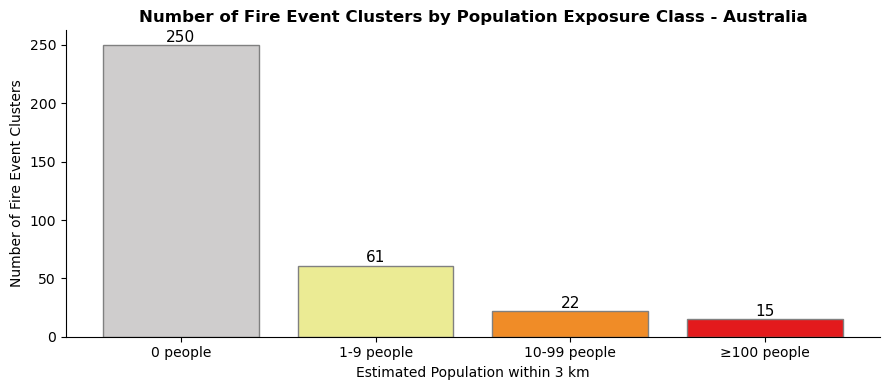

In [629]:
# Figure 1: population count within buffer per class
# Data for plot
labels = ["0 people", "1-9 people", "10-99 people", "≥100 people"]
counts = [
    (aus_clustered_fire_gdf["pop_sum_3km"] == 0).sum(),
    ((aus_clustered_fire_gdf["pop_sum_3km"] >= 1) & (aus_clustered_fire_gdf["pop_sum_3km"] < 10)).sum(),
    ((aus_clustered_fire_gdf["pop_sum_3km"] >= 10) & (aus_clustered_fire_gdf["pop_sum_3km"] < 100)).sum(),
    (aus_clustered_fire_gdf["pop_sum_3km"] >= 100).sum()
]
colors = ["#CFCDCD", "#ebeb94", "#f08c27", "#e31a1c"]

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, counts, color=colors, edgecolor="grey")

# Add count labels on bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(count), ha="center", va="bottom", fontsize=11)

ax.set_title("Number of Fire Event Clusters by Population Exposure Class - Australia", fontweight="bold")
ax.set_xlabel("Estimated Population within 3 km")
ax.set_ylabel("Number of Fire Event Clusters")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/figure1_population_count_per_class.png", dpi=150)
plt.show()

In [630]:
# Regional analysis per state
print("Regional Analysis: Population within 3km buffer by State")
regional = aus_clustered_fire_gdf.groupby("STE_NAME21").agg(
    n_clusters       = ("cluster_id", "count"),
    mean_pop         = ("pop_sum_3km", "mean"),
    max_pop          = ("pop_sum_3km", "max"),
    more100people_clusters = ("pop_sum_3km", lambda x: (x >= 100).sum())
).round(1).sort_values("more100people_clusters", ascending=False)

print(regional)

Regional Analysis: Population within 3km buffer by State
                    n_clusters  mean_pop  max_pop  more100people_clusters
STE_NAME21                                                               
Tasmania                    14     235.9   2764.5                       4
Northern Territory         219       1.9    192.6                       2
New South Wales             18      37.3    374.6                       2
Victoria                     6     186.2    613.6                       2
South Australia              3    1377.4   4010.8                       2
Western Australia           97       7.7    291.9                       2
Queensland                 104      13.4   1217.1                       1


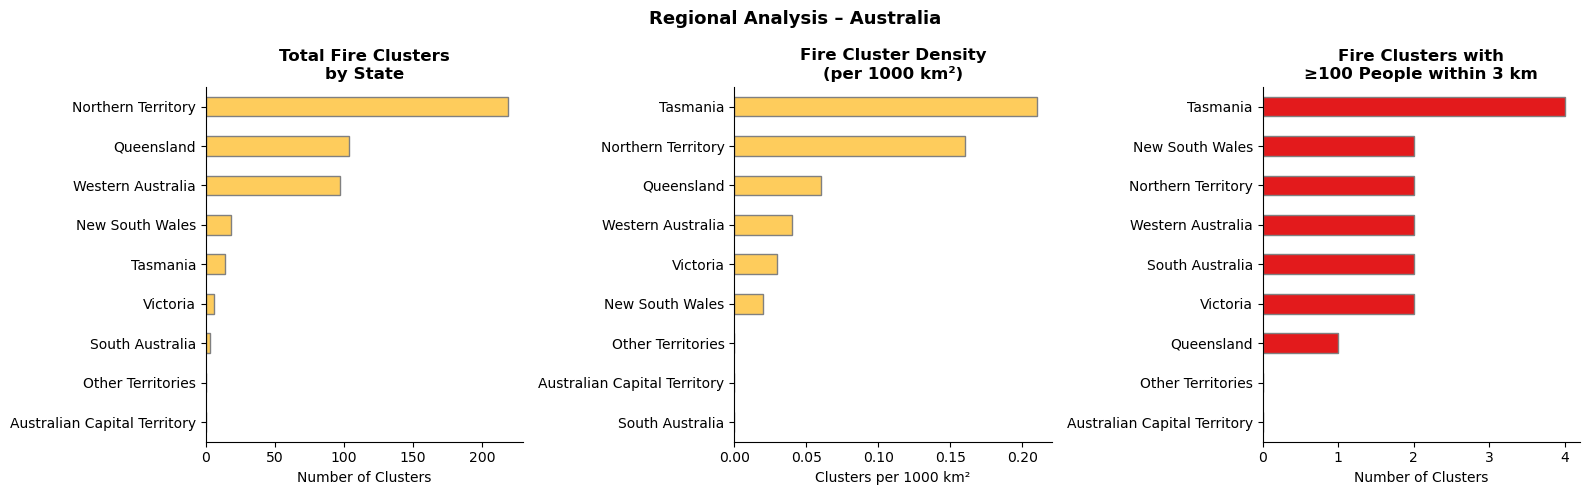

In [631]:
# Get all states from Australia shapefile
all_states = australia.set_index("STE_NAME21")["AREASQKM21"]
all_states = all_states[all_states.index != "Outside Australia"]

# Reindex regional to include all states (fills missing with 0/NaN)
regional = regional.reindex(all_states.index, fill_value=0)

# Add area
regional["area_km2"] = all_states
regional["clusters_per_1000km2"] = (regional["n_clusters"] / regional["area_km2"] * 1000).round(2)

# Figure2: Includes three subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Subplot 1: Number of clusters per state
regional.sort_values("n_clusters").plot.barh(
    y="n_clusters", ax=axes[0], color="#fecc5c", edgecolor="grey", legend=False
)
axes[0].set_title("Total Fire Clusters\nby State", fontweight="bold")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("")
axes[0].spines[["top", "right"]].set_visible(False)

# Subplot 2: Cluster density per 1000 km²
regional.sort_values("clusters_per_1000km2").plot.barh(
    y="clusters_per_1000km2", ax=axes[1], color="#fecc5c", edgecolor="grey", legend=False
)
axes[1].set_title("Fire Cluster Density\n(per 1000 km²)", fontweight="bold")
axes[1].set_xlabel("Clusters per 1000 km²")
axes[1].set_ylabel("")
axes[1].spines[["top", "right"]].set_visible(False)

# Subplot 3: Clusters with >=100 people per state
regional.sort_values("more100people_clusters").plot.barh(
    y="more100people_clusters", ax=axes[2], color="#e31a1c", edgecolor="grey", legend=False
)
axes[2].set_title("Fire Clusters with\n≥100 People within 3 km", fontweight="bold")
axes[2].set_xlabel("Number of Clusters")
axes[2].set_ylabel("")
axes[2].spines[["top", "right"]].set_visible(False)

plt.suptitle("Regional Analysis – Australia", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/figure2_regional_analysis.png", dpi=150)
plt.show()


In [632]:
# List of fire events that might affect most people within 3km radius
top10 = (
    aus_clustered_fire_gdf
    .sort_values("pop_sum_3km", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

In [ ]:
print("Top 10 Fire Clusters by Population Exposure")
print(top10[["cluster_id", "STE_NAME21", "pop_sum_3km", "frp", "n_points", "h_confidence", "n_confidence"]].to_string(index=False))
print("")
print(f"Top 10 clusters account for {top10['pop_sum_3km'].sum():.0f} people")
print(f"Share of total exposed population: {top10['pop_sum_3km'].sum() / aus_clustered_fire_gdf['pop_sum_3km'].sum() * 100:.1f}%")
print(f"Mean FRP of top 10 clusters: {top10['frp'].mean():.1f} MW")
print(f"Mean detections of top 10 clusters: {top10['n_points'].mean():.1f}")

=== Top 10 Fire Clusters by Population Exposure ===
 cluster_id         STE_NAME21  pop_sum_3km       frp  n_points  h_confidence  n_confidence
         56    South Australia  4010.772252  7.840000         2             0             2
         42           Tasmania  2764.499911  8.920000         1             0             1
         17         Queensland  1217.055867  6.750000         2             0             2
         51           Victoria   613.641498  7.870000         1             0             1
         53           Victoria   457.825388 14.060000         2             0             2
         59    New South Wales   374.616219  6.600000         1             0             1
        442  Western Australia   291.946676  6.380000         2             0             2
         97 Northern Territory   192.589539 10.140000         1             0             1
         62    New South Wales   162.694846 49.223333         3             1             2
         98 Northern Territo

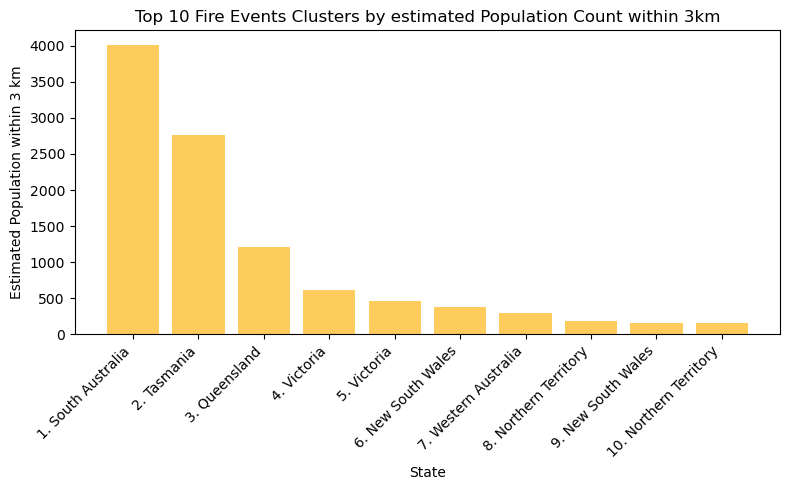

In [634]:
# Figure 3: 10 Fire Events with highest population count
# Define the labels with rank and state concatenated together
labels = (top10.index + 1).astype(str) +". "+ top10["STE_NAME21"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    labels,
    top10["pop_sum_3km"],
    color="#fecc5c"
)

ax.set_ylabel("Estimated Population within 3 km")
ax.set_xlabel("State")
ax.set_title("Top 10 Fire Events Clusters by estimated Population Count within 3km")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/figure3_top10_fire_clusters.png", dpi=300)
plt.show()